<a href="https://colab.research.google.com/github/nitaisutradhar/Heart-Disease-Prediction/blob/main/A_9_Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **KNN, Decision Trees & Random Forests**

### Nitai Chandra Sutradhar

---

## **Project Goal**
Predict whether a patient has heart disease based on medical measurements

## **Dataset:**
- **Name:** Heart Disease Dataset
- **Samples:** 1024 patients
- **Features:** 13 medical measurements
- **Target:** Outcome (0 = no disease and 1 = disease)

---

## **Table of Contents**

1. [Theory: Classification Algorithms](#theory)
2. [Import Libraries](#import)
3. [Load Dataset](#load)
4. [Data Exploration](#explore)
5. [Data Preparation](#prepare)
6. [Model 1: KNN](#knn)
7. [Model 2: Decision Tree](#dt)
8. [Model 3: Random Forest](#rf)
9. [Model Comparison](#compare)

---

<a id='import'></a>
## **2. Import Libraries**

In [ ]:
# Data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Settings
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


<a id='load'></a>
## **3. Load Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/Assignment 9/heart.csv')
print("✅ Dataset loaded successfully!")
print(f"\n📊 Dataset Shape: {df.shape}")

Mounted at /content/drive
✅ Dataset loaded successfully!

📊 Dataset Shape: (1025, 14)


<a id='explore'></a>
## **4. Data Exploration**

Let's understand our data!

In [ ]:
# View first 5 rows
print("📋 First 5 Patients:")
df.head()

📋 First 5 Patients:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
# Dataset information
print("📊 Dataset Information:")
df.info()

📊 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
# Statistical summary
print("📈 Statistical Summary:")
df.describe().T

📈 Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


target
1    526
0    499
Name: count, dtype: int64


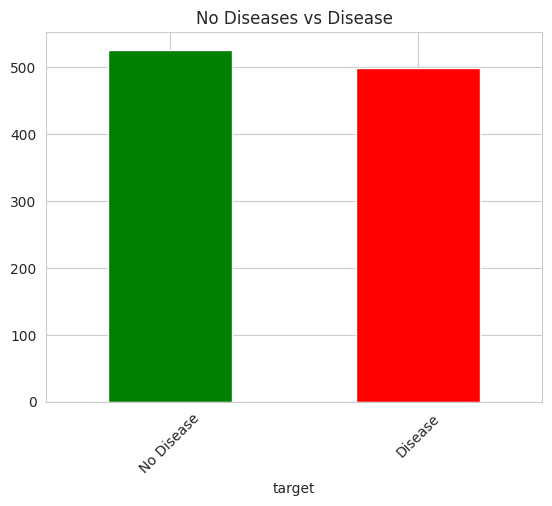

In [ ]:
# Show distribution
print(df['target'].value_counts())

# Plot
df['target'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('No Diseases vs Disease')
plt.xticks([0, 1], ['No Disease', 'Disease'], rotation=45)
plt.show()

<a id='prepare'></a>
## **5. Data Preparation**

Prepare data for machine learning models

In [ ]:
# Separate Features (X) and Target (y)
X = df.drop('target', axis=1)  # All columns except Outcome
y = df['target']  # Only the Outcome column

print("✅ Features (X):")
print(f"   Shape: {X.shape}")
print(f"   Columns: {X.columns.tolist()}")

print("\n✅ Target (y):")
print(f"   Shape: {y.shape}")
print(f"   Values: 0 (No Diseases) and 1 (Diseases)")

✅ Features (X):
   Shape: (1025, 13)
   Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

✅ Target (y):
   Shape: (1025,)
   Values: 0 (No Diseases) and 1 (Diseases)


In [ ]:
# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=20
)

print("✅ Data Split:")
print(f"   Training: {X_train.shape[0]} patients ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Testing:  {X_test.shape[0]} patients ({X_test.shape[0]/len(df)*100:.0f}%)")

✅ Data Split:
   Training: 820 patients (80%)
   Testing:  205 patients (20%)


In [ ]:
# Feature Scaling (IMPORTANT for KNN!)
print("⚙️ Scaling features...\n")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed!")

⚙️ Scaling features...

✅ Feature scaling completed!




```
# This is formatted as code
```

<a id='knn'></a>
## **6. Model 1: K-Nearest Neighbors (KNN)**

Best K: 1


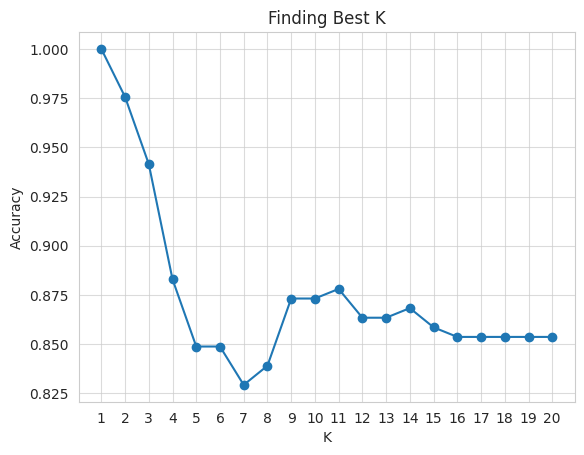

In [ ]:
# Find best K
accuracies = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

best_k = accuracies.index(max(accuracies)) + 1
print(f"Best K: {best_k}")

# Plot
plt.plot(range(1, 21), accuracies, marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(range(1, 21))
plt.title('Finding Best K')
plt.grid(alpha=0.7)

plt.show()

In [ ]:
# Train final KNN model
print(f"\n🤖 Training KNN with K = {best_k}...\n")

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("✅ KNN Model trained!")
print(f"\n📊 KNN Accuracy: {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)")


🤖 Training KNN with K = 1...

✅ KNN Model trained!

📊 KNN Accuracy: 1.0000 (100.00%)



📋 KNN Classification Report:
              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00        99
     Disease       1.00      1.00      1.00       106

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



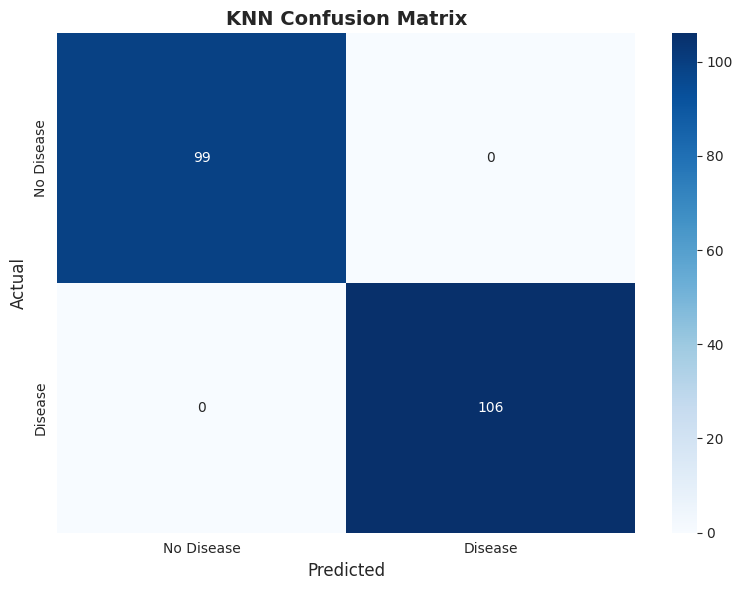

In [ ]:
# Evaluation
print("\n📋 KNN Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_knn, target_names=['No Disease', 'Disease']))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('KNN Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*60)

<a id='dt'></a>
## **7. Model 2: Decision Tree**

In [ ]:
# Train Decision Tree
print("🌳 Training Decision Tree...\n")

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,          # Limit depth to avoid overfitting
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train, y_train)  # No scaling needed
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("✅ Decision Tree trained!")
print(f"\n📊 Decision Tree Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")

🌳 Training Decision Tree...

✅ Decision Tree trained!

📊 Decision Tree Accuracy: 0.8780 (87.80%)



📋 Decision Tree Classification Report:
              precision    recall  f1-score   support

  No Disease       0.91      0.83      0.87        99
     Disease       0.85      0.92      0.89       106

    accuracy                           0.88       205
   macro avg       0.88      0.88      0.88       205
weighted avg       0.88      0.88      0.88       205



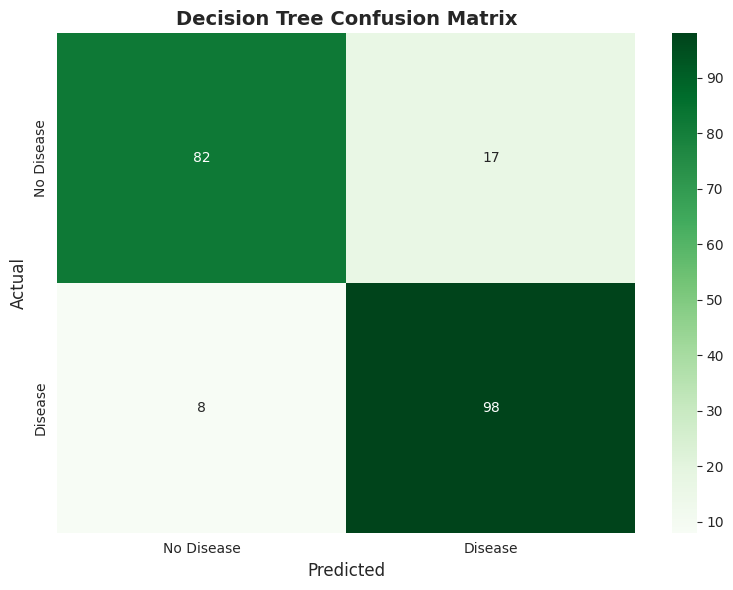

In [ ]:
# Evaluation
print("\n📋 Decision Tree Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Disease']))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Decision Tree Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*60)


⭐ Feature Importance (Decision Tree):
 Feature  Importance
      cp    0.379416
    thal    0.167015
      ca    0.140771
     age    0.108742
 thalach    0.059822
 oldpeak    0.035105
   exang    0.034657
   slope    0.029536
    chol    0.020221
 restecg    0.012450
trestbps    0.012265
     sex    0.000000
     fbs    0.000000


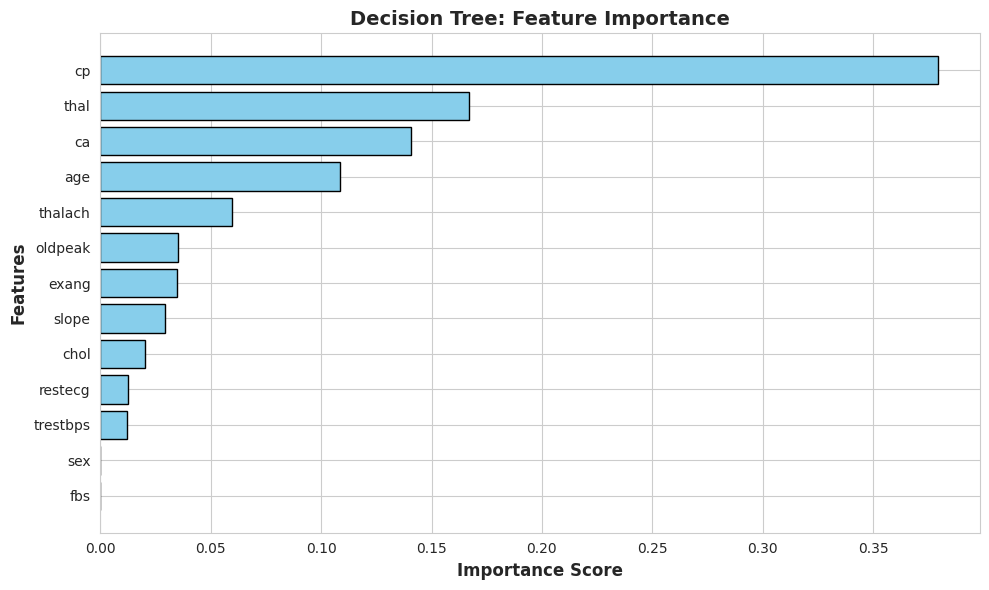


💡 These features are most important for prediction!



In [ ]:
# Feature Importance
print("\n⭐ Feature Importance (Decision Tree):")
print("=" * 60)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'],
         color='skyblue', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Decision Tree: Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n💡 These features are most important for prediction!")
print("\n" + "="*60)

<a id='rf'></a>
## **8. Model 3: Random Forest**

In [ ]:
# Train Random Forest
print("🌲🌳🌲 Training Random Forest...\n")

rf_model = RandomForestClassifier(
    n_estimators=100,     # 100 trees
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1             # Use all CPU cores
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("✅ Random Forest trained!")
print(f"   → {rf_model.n_estimators} trees created")
print(f"   → Each tree votes")
print(f"\n📊 Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

🌲🌳🌲 Training Random Forest...

✅ Random Forest trained!
   → 100 trees created
   → Each tree votes

📊 Random Forest Accuracy: 0.8585 (85.85%)



📋 Random Forest Classification Report:
              precision    recall  f1-score   support

  No Disease       0.90      0.80      0.84        99
     Disease       0.83      0.92      0.87       106

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205



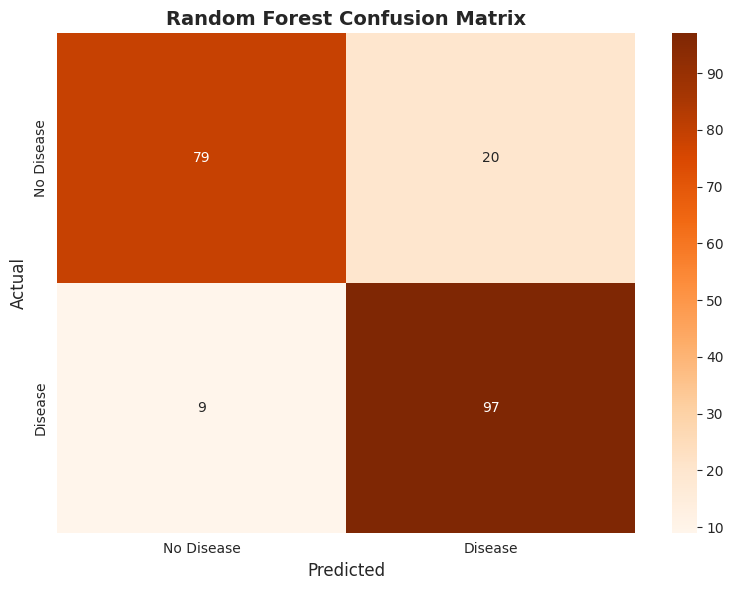

In [ ]:
# Evaluation
print("\n📋 Random Forest Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Disease']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Random Forest Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*60)


⭐ Feature Importance (Random Forest):
 Feature  Importance
      cp    0.175197
      ca    0.150996
    thal    0.144782
 oldpeak    0.122238
   exang    0.105601
 thalach    0.093204
     age    0.057770
   slope    0.052965
    chol    0.033479
trestbps    0.029980
     sex    0.022918
 restecg    0.008943
     fbs    0.001928


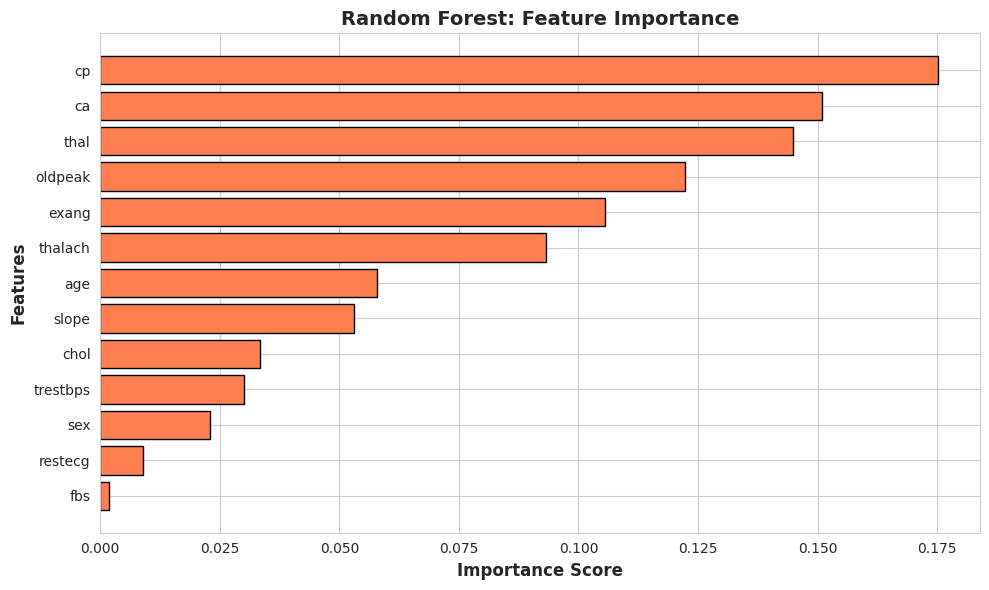


💡 Random Forest importance is more reliable!
   (Average of 100 trees)



In [ ]:
# Feature Importance
print("\n⭐ Feature Importance (Random Forest):")
print("=" * 60)

rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(rf_feature_importance.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(rf_feature_importance['Feature'], rf_feature_importance['Importance'],
         color='coral', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Random Forest: Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n💡 Random Forest importance is more reliable!")
print("   (Average of 100 trees)")
print("\n" + "="*60)

<a id='compare'></a>
## **9. Model Comparison & Final Results**

In [ ]:
# Compare all models
print("\n🏆 FINAL MODEL COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [knn_accuracy, dt_accuracy, rf_accuracy],
    'Accuracy %': [f"{knn_accuracy*100:.2f}%", f"{dt_accuracy*100:.2f}%", f"{rf_accuracy*100:.2f}%"]
})

comparison = comparison.sort_values('Accuracy', ascending=False)
print("\n" + comparison.to_string(index=False))

best_model = comparison.iloc[0]['Model']
best_acc = comparison.iloc[0]['Accuracy']

print(f"\n🥇 WINNER: {best_model}")
print(f"   Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print("\n" + "="*60)


🏆 FINAL MODEL COMPARISON

        Model  Accuracy Accuracy %
          KNN  1.000000    100.00%
Decision Tree  0.878049     87.80%
Random Forest  0.858537     85.85%

🥇 WINNER: KNN
   Accuracy: 1.0000 (100.00%)



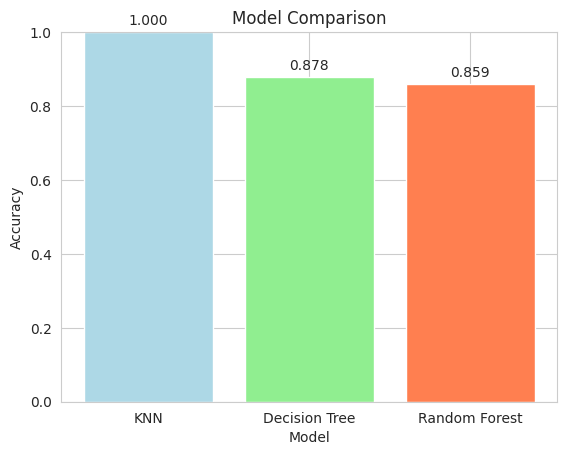

In [ ]:
# Visual Comparison
plt.bar(comparison['Model'], comparison['Accuracy'], color=['lightblue', 'lightgreen', 'coral'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim([0, 1])

# Add values on bars
for i, acc in enumerate(comparison['Accuracy']):
    plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center')

plt.show()